[Reference](https://pub.towardsai.net/how-recommendation-systems-actually-work-dc32f203ea7e)

# Part 1: Loading and Preparing the Data

In [1]:
# PART 1: SETUP AND DATA LOADING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load ratings data
ratings = pd.read_csv(
    'https://files.grouplens.org/datasets/movielens/ml-100k/u.data',
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

# Load movie titles
movies = pd.read_csv(
    'https://files.grouplens.org/datasets/movielens/ml-100k/u.item',
    sep='|',
    encoding='latin-1',
    names=['movie_id', 'title', 'release_date', 'video_release_date',
           'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
           'Thriller', 'War', 'Western'],
    usecols=range(24)
)

print("Dataset loaded successfully")
print(f"Total ratings: {len(ratings):,}")
print(f"Total users: {ratings['user_id'].nunique():,}")
print(f"Total movies: {ratings['movie_id'].nunique():,}")

# Split data: 80% train, 20% test
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# Create user-item matrix from training data
train_matrix = train_data.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

print(f"\nTraining set: {len(train_data):,} ratings")
print(f"Test set: {len(test_data):,} ratings")
print(f"Matrix shape: {train_matrix.shape}")

Dataset loaded successfully
Total ratings: 100,000
Total users: 943
Total movies: 1,682

Training set: 80,000 ratings
Test set: 20,000 ratings
Matrix shape: (943, 1653)


# Part 2: Popularity and Collaborative Filtering

In [2]:
# PART 2: POPULARITY-BASED AND ITEM-BASED COLLABORATIVE FILTERING

# Approach 1: Popularity-Based Recommender
def popularity_recommender(n=10, min_ratings=50):
    stats = train_data.groupby('movie_id').agg({
        'rating': ['count', 'mean']
    }).reset_index()
    stats.columns = ['movie_id', 'rating_count', 'rating_mean']
    stats = stats[stats['rating_count'] >= min_ratings]
    stats = stats.sort_values('rating_mean', ascending=False)
    stats = stats.merge(movies[['movie_id', 'title']], on='movie_id')
    return stats[['title', 'rating_count', 'rating_mean']].head(n)

print("\nTop 10 Popular Movies:")
print(popularity_recommender(10))

# Approach 2: Item-Based Collaborative Filtering
print("\nCalculating movie similarity matrix...")
train_matrix_filled = train_matrix.fillna(0)
item_similarity_matrix = cosine_similarity(train_matrix_filled.T)
item_similarity_df = pd.DataFrame(
    item_similarity_matrix,
    index=train_matrix.columns,
    columns=train_matrix.columns
)
print(f"Similarity matrix shape: {item_similarity_df.shape}")

def find_similar_movies(movie_id, n=10):
    if movie_id not in item_similarity_df.columns:
        return f"Movie ID {movie_id} not found"
    similarities = item_similarity_df[movie_id].sort_values(ascending=False)
    similar_movies = similarities.iloc[1:n+1]
    results = pd.DataFrame({
        'movie_id': similar_movies.index,
        'similarity': similar_movies.values
    })
    results = results.merge(movies[['movie_id', 'title']], on='movie_id')
    return results[['title', 'similarity']]

print("\nMovies similar to 'Toy Story' (ID=1):")
print(find_similar_movies(1, n=5))

def predict_rating_item_based(user_id, movie_id, k=10):
    default_rating = train_data['rating'].mean()
    if movie_id not in item_similarity_df.columns or user_id not in train_matrix.index:
        return default_rating
    user_ratings = train_matrix.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return default_rating
    similarities = item_similarity_df[movie_id][user_ratings.index]
    top_similar = similarities.nlargest(k)
    if len(top_similar) == 0 or top_similar.sum() == 0:
        return default_rating
    weighted_sum = (top_similar * user_ratings[top_similar.index]).sum()
    return weighted_sum / top_similar.sum()


Top 10 Popular Movies:
                                               title  rating_count  \
0  Wallace & Gromit: The Best of Aardman Animatio...            51   
1                            Schindler's List (1993)           236   
2                   Shawshank Redemption, The (1994)           228   
3                                  Casablanca (1942)           189   
4                              Close Shave, A (1995)            84   
5                         Usual Suspects, The (1995)           219   
6                         Wrong Trousers, The (1993)            93   
7                                Citizen Kane (1941)           158   
8                                 Rear Window (1954)           167   
9                                   Star Wars (1977)           451   

   rating_mean  
0     4.509804  
1     4.474576  
2     4.456140  
3     4.428571  
4     4.416667  
5     4.410959  
6     4.387097  
7     4.379747  
8     4.377246  
9     4.370288  

Calculating movie

# Part 3: Matrix Factorization with SVD (Singular Value Decomposition)

In [3]:

# PART 3: MATRIX FACTORIZATION WITH SVD

print("\nTraining SVD model...")

# Prepare data for SVD
train_matrix_for_svd = train_matrix.copy()
user_means = train_matrix_for_svd.mean(axis=1)
train_matrix_for_svd = train_matrix_for_svd.sub(user_means, axis=0).fillna(0)

# Apply SVD
n_factors = 50
svd = TruncatedSVD(n_components=n_factors, random_state=42)
user_factors = svd.fit_transform(train_matrix_for_svd)
item_factors = svd.components_.T

print(f"SVD model trained with {n_factors} latent factors")
print(f"User factors: {user_factors.shape}")
print(f"Item factors: {item_factors.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum()*100:.1f}%")

def predict_rating_svd(user_id, movie_id):
    default_rating = train_data['rating'].mean()
    if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
        return default_rating
    user_idx = list(train_matrix.index).index(user_id)
    movie_idx = list(train_matrix.columns).index(movie_id)
    predicted = np.dot(user_factors[user_idx], item_factors[movie_idx]) + user_means.iloc[user_idx]
    return np.clip(predicted, 1, 5)


Training SVD model...
SVD model trained with 50 latent factors
User factors: (943, 50)
Item factors: (1653, 50)
Variance explained: 36.4%


# Part 4: Evaluating Performance


Evaluating all models on test set...
Generating Item-Based CF predictions...
Generating SVD predictions...

Model Comparison Results:
        Model     RMSE      MAE
   Popularity 1.123860 0.941955
Item-Based CF 0.965005 0.752186
          SVD 1.003570 0.796130

Best Model: Item-Based CF


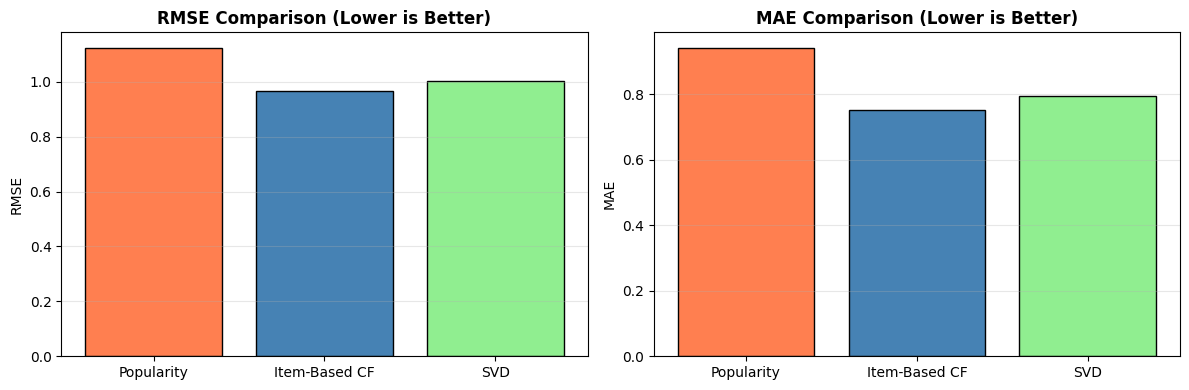

In [4]:
# PART 4: MODEL EVALUATION AND COMPARISON

print("\nEvaluating all models on test set...")

test_users = test_data['user_id'].values
test_movies = test_data['movie_id'].values
test_actuals = test_data['rating'].values

# Model 1: Popularity baseline
pop_predictions = np.array([train_data['rating'].mean()] * len(test_data))
pop_rmse = np.sqrt(mean_squared_error(test_actuals, pop_predictions))
pop_mae = mean_absolute_error(test_actuals, pop_predictions)

# Model 2: Item-Based CF
print("Generating Item-Based CF predictions...")
item_predictions = []
for user, movie in zip(test_users, test_movies):
    item_predictions.append(predict_rating_item_based(user, movie))
item_predictions = np.array(item_predictions)
item_rmse = np.sqrt(mean_squared_error(test_actuals, item_predictions))
item_mae = mean_absolute_error(test_actuals, item_predictions)

# Model 3: SVD
print("Generating SVD predictions...")
svd_predictions = []
for user, movie in zip(test_users, test_movies):
    svd_predictions.append(predict_rating_svd(user, movie))
svd_predictions = np.array(svd_predictions)
svd_rmse = np.sqrt(mean_squared_error(test_actuals, svd_predictions))
svd_mae = mean_absolute_error(test_actuals, svd_predictions)

# Results
results = pd.DataFrame({
    'Model': ['Popularity', 'Item-Based CF', 'SVD'],
    'RMSE': [pop_rmse, item_rmse, svd_rmse],
    'MAE': [pop_mae, item_mae, svd_mae]
})

print("\nModel Comparison Results:")
print(results.to_string(index=False))
print(f"\nBest Model: {results.loc[results['RMSE'].idxmin(), 'Model']}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['coral', 'steelblue', 'lightgreen']

axes[0].bar(results['Model'], results['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('RMSE Comparison (Lower is Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(results['Model'], results['MAE'], color=colors, edgecolor='black')
axes[1].set_title('MAE Comparison (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Part 5: Generating Recommendations

In [5]:
# PART 5: GENERATE PERSONALIZED RECOMMENDATIONS

def get_recommendations(user_id, n=10, method='svd'):
    rated_movies = set(ratings[ratings['user_id'] == user_id]['movie_id'].values)
    all_movies = movies['movie_id'].values
    unrated_movies = [m for m in all_movies if m not in rated_movies]

    if method == 'popularity':
        pop_recs = popularity_recommender(n=100)
        pop_recs = pop_recs[~pop_recs['title'].isin(
            movies[movies['movie_id'].isin(rated_movies)]['title']
        )]
        return pop_recs.head(n)

    predictions = []
    if method == 'svd':
        for movie_id in unrated_movies:
            predictions.append((movie_id, predict_rating_svd(user_id, movie_id)))
    elif method == 'item_based':
        for movie_id in unrated_movies:
            predictions.append((movie_id, predict_rating_item_based(user_id, movie_id)))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]
    recs_df = pd.DataFrame(top_n, columns=['movie_id', 'predicted_rating'])
    recs_df = recs_df.merge(movies[['movie_id', 'title']], on='movie_id')
    return recs_df[['title', 'predicted_rating']]

# Example: Get recommendations for User 196
USER_ID = 196

user_history = ratings[ratings['user_id'] == USER_ID].merge(
    movies[['movie_id', 'title']], on='movie_id'
).sort_values('rating', ascending=False)

print(f"\nUser {USER_ID} Profile:")
print(f"Total movies rated: {len(user_history)}")
print(f"Average rating: {user_history['rating'].mean():.2f}")

print(f"\nTop 5 Movies Rated by User {USER_ID}:")
print(user_history[['title', 'rating']].head(5).to_string(index=False))

print(f"\nTop 10 Recommendations for User {USER_ID} (SVD method):")
recommendations = get_recommendations(USER_ID, n=10, method='svd')
for i, row in recommendations.iterrows():
    print(f"{i+1:2}. {row['title']:<50} {row['predicted_rating']:.2f}")

# Explain why a movie was recommended
def explain_recommendation(user_id, movie_id, top_n=5):
    movie_title = movies[movies['movie_id'] == movie_id]['title'].values
    if len(movie_title) == 0:
        return "Movie not found"
    movie_title = movie_title[0]

    highly_rated = ratings[(ratings['user_id'] == user_id) & (ratings['rating'] >= 4)]['movie_id'].values
    if movie_id not in item_similarity_df.columns:
        return "Movie not in similarity matrix"

    similarities = item_similarity_df[movie_id][highly_rated].sort_values(ascending=False).head(top_n)
    if len(similarities) == 0:
        return "No similar movies found"

    explanation = pd.DataFrame({'movie_id': similarities.index, 'similarity': similarities.values})
    explanation = explanation.merge(movies[['movie_id', 'title']], on='movie_id')
    explanation = explanation.merge(ratings[ratings['user_id'] == user_id][['movie_id', 'rating']], on='movie_id')

    print(f"\nWhy we recommend '{movie_title}':")
    print("Because you rated these similar movies highly:")
    print(explanation[['title', 'rating', 'similarity']].to_string(index=False))
    return explanation

# Explain top recommendation
top_rec_id = movies[movies['title'] == recommendations.iloc[0]['title']]['movie_id'].values[0]
explain_recommendation(USER_ID, top_rec_id)


User 196 Profile:
Total movies rated: 39
Average rating: 3.62

Top 5 Movies Rated by User 196:
                            title  rating
               Stand by Me (1986)       5
Ace Ventura: Pet Detective (1994)       5
      Fish Called Wanda, A (1988)       5
                      Babe (1995)       5
   American President, The (1995)       5

Top 10 Recommendations for User 196 (SVD method):
 1. Piano, The (1993)                                  3.79
 2. Evita (1996)                                       3.77
 3. Shining, The (1980)                                3.76
 4. Air Force One (1997)                               3.76
 5. Devil's Own, The (1997)                            3.76
 6. Ransom (1996)                                      3.74
 7. Austin Powers: International Man of Mystery (1997) 3.73
 8. Sense and Sensibility (1995)                       3.73
 9. Space Jam (1996)                                   3.72
10. Dirty Dancing (1987)                               3.72



,movie_id,similarity,title,rating
0,655,0.376085,Stand by Me (1986),5
1,8,0.359580,Babe (1995),5
2,153,0.349637,"Fish Called Wanda, A (1988)",5
3,238,0.328216,Raising Arizona (1987),4
4,382,0.319361,"Adventures of Priscilla, Queen of the Desert, ...",4
